# Projects in ML & AI HW 6 Part 2 - Izaak King

# Mini Research Task on Denoising Diffusion Probabilistic Models

## Technical Sources

### Denoising Diffusion Probabilistic Models

*Denoising Diffusion Probabilistic Models* by Jonathan Ho, Ajay Jain, and Pieter Abbeel is the foundational paper that formally introduces diffusion models and defines their probabilistic framework and training objective.

Link: https://arxiv.org/abs/2006.11239

### Improved Denoising Diffusion Probabilistic Models

*Improved Denoising Diffusion Probabilistic Models* by Alex Nichol and Prafulla Dhariwal. This paper builds off the work of Ho, Jain and Abbeel. It introduces key optimizations, such as learning the variance of the reverse process (rather than keeping it fixed) and a cosine-based noise schedule. These tweaks allowed diffusion models to achieve higher log-likelihoods and generate high-quality images with fewer steps.

Link: https://arxiv.org/abs/2102.09672

## Method Analysis

### The Problem

Denoising Diffusion Probabilistic Models (DDPMs) address the challenge of generating high-quality and diverse data, such as images, in a stable and controllable manner. Earlier generative models, such as GANs and VAEs, are either hindered by training instability or produce outputs that are blurry or lacked diversity. The work by Ho, Jain, and Abbeel (2020) formulates data generation as a sequential denoising problem. Instead of generating an image in a single step, the model learns to gradually convert random noise into structured data through a multi-step reverse diffusion process. This probabilistic approach allows the model to capture complex data distributions while maintaining training stability, providing a principled alternative to earlier generative methods.

### The Core Idea

The core idea of diffusion models involves two complementary processes, a forward process that adds noise to the data and a learned reverse process that removes noise to reconstruct the original data. In the forward process, Gaussian noise is incrementally applied to an input sample across many timesteps until it becomes nearly indistinguishable from pure noise. The reverse process then trains a neural network to predict and remove this noise at each timestep. By learning to denoise progressively, the model reduces the difficult task of generating a complex sample all at once into a series of simpler regression problems. Nichol and Dhariwal (2021) further improve this framework by introducing a cosine-based noise schedule and by learning the variance of the reverse process, which allows for fewer sampling steps while maintaining high-quality image generation.

### The Training Objective

While the mathematical formulation of diffusion models is rooted in variational bounds, Ho, Jain, and Abbeel (2020) discovered that the model performs best when optimizing a simplified surrogate loss function. Instead of predicting the exact original image or the entire noise distribution, the neural network (typically a U-Net) is trained to predict the specific noise that was added to the image at a given timestep. The loss is effectively the Mean Squared Error (MSE) between the true noise and the predicted noise. This simple, reweighted objective focuses the model on the most difficult denoising steps and contributes significantly to the high quality of the generated samples.

### The Architecture

For architecture, the neural network in DDPMs is designed to handle both noisy input and timestep information to perform denoising effectively. Ho et al. (2020) use a convolutional architecture conditioned on the timestep, which allows the model to adapt its predictions based on how much noise is present. Nichol and Dhariwal (2021) build on this by optimizing the noise schedule and variance parameterization, which enhances the network's ability to predict the noise at each step accurately. This combination of convolutional layers and timestep conditioning forms the backbone of the model, enabling it to iteratively refine a noisy sample into a realistic image while maintaining both global structure and fine details.

### Applications
DDPMs and their improved variants have revolutionized generative AI, becoming the foundational technology behind state-of-the-art text-to-image models such as OpenAI's DALL-E 2, Google's Imagen, and Stability AI's Stable Diffusion. Beyond image generation, diffusion models are increasingly applied to audio synthesis, video generation, and even 3D asset creation due to their unparalleled output quality and diversity.

### Limitations
The primary limitation of standard DDPMs is their computational cost during inference. Because the reverse diffusion process requires passing the data through the network hundreds or thousands of times sequentially, generating a single sample is significantly slower than single-step models like GANs. While improved models and techniques like Latent Diffusion (running the process in a compressed latent space) and advanced ODE solvers (like DDIMs) have drastically reduced sampling times, real-time generation remains a challenging area of active research.

## Hands-On-Component: Effect of Denoising Steps on Image Quality

In this section we explore how the number of denoising steps in a diffusion model affects the quality of generated images. According to Ho et al. (2020) and Nichol & Dhariwal (2021), increasing the number of steps improves image fidelity but comes at the cost of longer computation. By comparing outputs with fewer and more steps, we can visually and quantitatively observe the tradeoff.


Use a pretrained DDPM (from Hugging Face Diffusers) trained on a small dataset. We generate images with 10, 50, 100, and 200 denoising steps, comparing outputs visually to see how differences in steps affects quality of images.

We expect that fewer steps should lead to faster but blurrier and lower-quality images, moderate steps lead to decent quality, and many steps lead to the highest quality, but has a slower run-time.

Lastly, we will include a table showing number of steps vs sample quality, and also display generated images for visual comparison.

### Model and Dataset Selection

For this research task, we use the ```google/ddpm-cifar10-32``` pretrained model, which was trained on the ```CIFAR-10``` dataset. This dataset consists of 60,000 low-resolution color images (32 x 32 pixels) across 10 balanced classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck).

Through the use of this pretrained pipeline, we can analyze how the DDPM architecture captures the features of real-world objects at a computationally manageable scale. Using this model provides a practical benchmark for understanding the denoising process without the extreme resource requirements of high-resolution datasets like ImageNet.

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

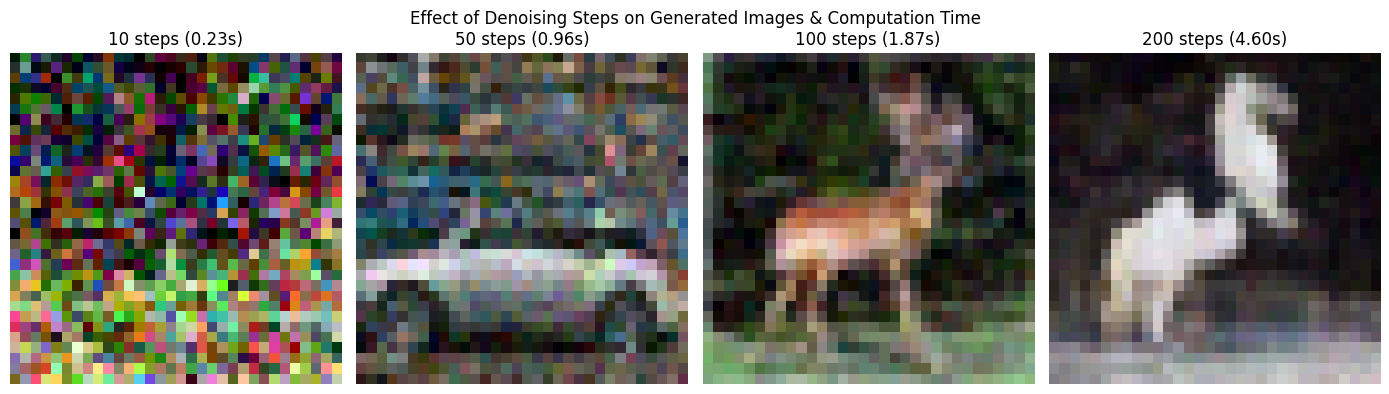

In [3]:
import warnings
warnings.filterwarnings('ignore')

from diffusers import DDPMPipeline
import torch
import matplotlib.pyplot as plt
import time

# Load pretrained DDPM model (CIFAR-10 small model)
pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32", use_safetensors=False)
pipe.to("cuda")

# Define number of denoising steps to compare
steps_list = [10, 50, 100, 200]
generated_images = []
generation_times = []

# Generate one image per step count
seed = 777  # one seed per number of steps
for steps in steps_list:
    generator = torch.Generator("cuda").manual_seed(seed)

    start_time = time.time()
    image = pipe(num_inference_steps=steps, generator=generator).images[0]
    end_time = time.time()

    generated_images.append(image)
    generation_times.append(end_time - start_time)

# Plot results
fig, axes = plt.subplots(1, 4, figsize=(14,4))
for ax, img, steps, gen_time in zip(axes, generated_images, steps_list, generation_times):
    ax.imshow(img)
    ax.set_title(f"{steps} steps ({gen_time:.2f}s)")
    ax.axis("off")

plt.suptitle("Effect of Denoising Steps on Generated Images & Computation Time")
plt.tight_layout()
plt.show()


### Analysis Table

| Number of Steps | Image Quality | Notes |
|-----------------|---------------|-------|
| 10              | Very Low / Random  | Very fast generation, no distinguishable objects, random pattern |
| 50              | Moderately Blurry        |  Fast generation, distinguishable automobile, poor image quality|
| 100             | High          | Moderate generation, reasonable sharpness, distinguishable deer |
| 200             | High          | Relatively slow generation, very sharp and detailed, distinguishable horse |

**Observations:**  
- As expected, the image quality improves as the number of denoising steps increases.
- At 10 steps, the image is random and lacks details.  
- At 50 steps, the structure becomes clearer and the object is distinguishable, but the image remains blurry.
- At 100 steps, the generated image is noticeably more detailed, but is entirely sharp.
- At 200 steps the image is very sharp. Although it takes the longest to train, it clearly the best quality.

## Limitations, Risks, and Open Challenges



###High Computational Cost:

Diffusion models require a large number of forward and reverse steps to generate high-quality samples, which makes training and inference computationally expensive. Even with optimizations like the cosine noise schedule introduced by Nichol & Dhariwal (2021), generating a single high-resolution image can take several seconds to minutes on a GPU, limiting real-time applications.

### Sensitivity to Hyperparameters and Noise Schedules:

The quality of generated images is highly dependent on the choice of number of denoising steps, noise schedule, and variance parameters. Incorrect tuning can lead to blurry images, mode collapse, or outputs that do not resemble the intended data distribution. This sensitivity makes diffusion models harder to deploy robustly in production settings compared to more stable generative models like VAEs.


### Potential Bias and Misuse:

As with generative AI models as a whole, diffusion models can amplify biases present in the training data. For example, a model trained on biased or unbalanced datasets may generate stereotyped or harmful images. Additionally, because diffusion models can produce realistic synthetic images, there is a risk of misuse in deepfakes or misinformation.

## Proposed Extension / Follow-Up Experiment

A potential follow-up experiment would be to systematically evaluate the impact of different noise schedules on image quality and diversity. While the cosine noise schedule improves efficiency (Nichol & Dhariwal, 2021), we can examine how other schedules (e.g., linear, quadratic, or learnable schedules) affect the tradeoff between speed and fidelity.

The number of denoising steps would be kept constant, for example, at 50 steps, to isolate the effect of the schedule on the output. The generated images could then be compared both quantitatively, using metrics such as Fréchet Inception Distance (FID) and Inception Score (IS), and qualitatively, by visually inspecting image sharpness, detail, and diversity.

This analysis would help determine which noise schedule achieves the best tradeoff between sample quality, diversity, and computational efficiency, providing insights for optimizing diffusion models in practical applications.